In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error

## Analysis of Medical Insurance Records

In [34]:
data = pd.read_csv("/content/medical_insurance_project.csv")
# print(data)

# ================================== Analysing of Medical Insurance Records ===================================


print("Top 10 Rows of Data: \n",data.head(10))

print("\nNumber of Rows and Columns: \n",data.shape)

print("\nData Type stored in in each feature: ")
print(data.info())

print("\nChecking for Missing Data: \n",data.isnull().sum())
# There is no Nan or Missing Values in Records

print("\nChecking for Duplicate data: \n",data.duplicated().sum())
# Yes, There is 1 Duplicate Value in whole Dataset

print("\nDropping the Duplicate Value: ")
data = data.drop_duplicates()
print(data)

print("\nStatistical Analysis about Data: \n",data.describe())


Top 10 Rows of Data: 
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  33.440         1     no  southeast   8240.58960
7   37  female  27.740         3     no  northwest   7281.50560
8   37    male  29.830         2     no  northeast   6406.41070
9   60  female  25.840         0     no  northwest  28923.13692

Number of Rows and Columns: 
 (1338, 7)

Data Type stored in in each feature: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age 

## Analysis of Medical Charges(EDA)

11911.37345

Outliers (extreme value): 
       age     sex     bmi  children smoker     region      charges
14     27    male  42.130         0    yes  southeast  39611.75770
19     30    male  35.300         0    yes  southwest  36837.46700
23     34  female  31.920         1    yes  northeast  37701.87680
29     31    male  36.300         2    yes  southwest  38711.00000
30     22    male  35.600         0    yes  southwest  35585.57600
...   ...     ...     ...       ...    ...        ...          ...
1300   45    male  30.360         0    yes  southeast  62592.87309
1301   62    male  30.875         3    yes  northwest  46718.16325
1303   43    male  27.800         0    yes  southwest  37829.72420
1313   19  female  34.700         2    yes  southwest  36397.57600
1323   42  female  40.370         2    yes  southeast  43896.37630

[139 rows x 7 columns]

The distribution or spread of Medical Charges Data: 
 12110.359656344179


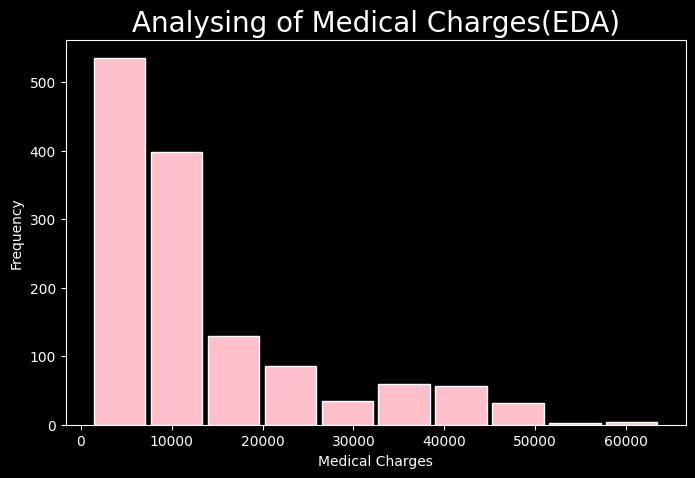


The Average Charges from Sex: 
 sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64 



In [35]:
# ================================== Analysis of Medical Charges(EDA) ===================================


# Checking for any ourtlier(Extreme value):

Q1 = data["charges"].quantile(0.25)
Q3 = data["charges"].quantile(0.75)

IQR = Q3 - Q1
print(IQR)

lower_part = Q1 - IQR*1.5
upper_part = Q3 + IQR*1.5

print("\nOutliers (extreme value): \n",data[(data["charges"]<lower_part) | (data["charges"] > upper_part)])

print("\nThe distribution or spread of Medical Charges Data: \n",data["charges"].std())

# The distribution of medical charges Data is idealy not good due to the some data very far away from the mean position

# The Outliers interupting the data analysis which make difficult to take insights from data

plt.style.use("dark_background")

plt.figure(figsize = (8,5))

plt.title("Analysis of Medical Charges(EDA)",fontsize = 20)

plt.xlabel("Medical Charges")
plt.ylabel("Frequency")

plt.hist(data["charges"],edgecolor = "white",color = "pink",rwidth = 0.9)
plt.show()

# The Distribution or Spread of Charges are in right skewed manner
#  (few strating data are high then there there is major data is stable or low)


print("\nThe Average Charges from Sex: \n",data.groupby("sex")["charges"].mean(),"\n")



## Analysis between Age And Medical Charges

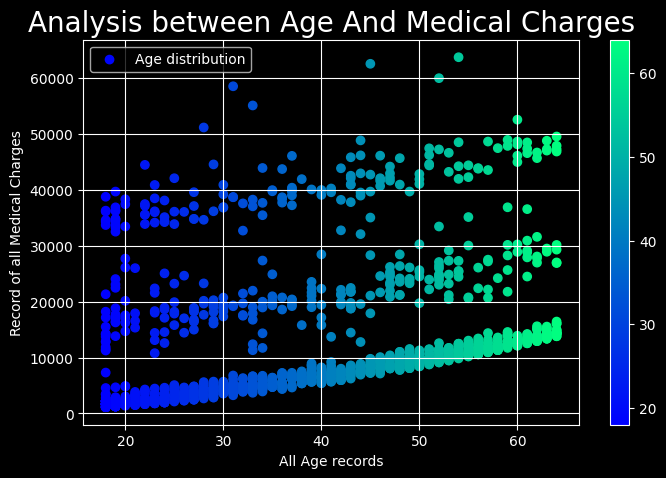


The Correlation between medical charges and Age is 'Positive correltion'
       Due to increaing with age medical charges also increases


Correlation between Medical Charges and Age : 
               age   charges
age      1.000000  0.298308
charges  0.298308  1.000000


In [36]:
# ================================== Analysis between Age And Medical Charges ================================


plt.figure(figsize = (8,5))

plt.title("Analysis between Age And Medical Charges",fontsize = 20)

plt.xlabel("All Age records")
plt.ylabel("Record of all Medical Charges")

plt.scatter(data["age"],data["charges"],c = data["age"],cmap = "winter",label = "Age distribution")

plt.legend()
plt.colorbar()
plt.grid()
plt.show()

# Most people medical charges were around between 0 to 15,000
# There was a very few records for high charges around 50,000 to 60,000
# There was a linear realtionship between charges and age ,The high age people having more charges

print("""\nThe Correlation between medical charges and Age is 'Positive correltion'
       Due to increaing with age medical charges also increases\n\n""")

print("Correlation between Medical Charges and Age : \n",data.loc[:,["age","charges"]].corr())


## Analysis between BMI and Medical Charges

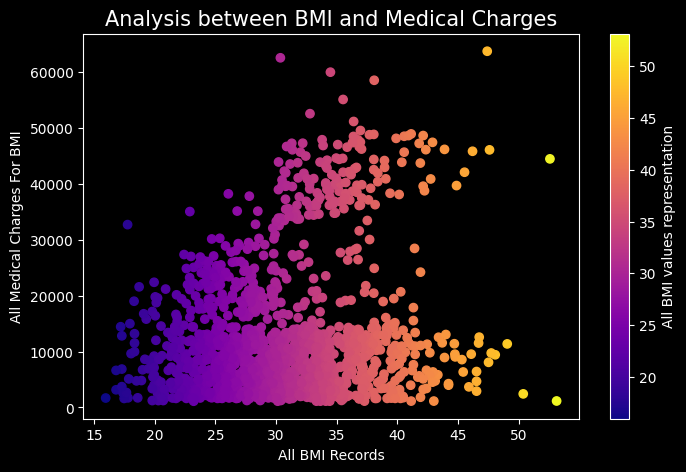


The Correlation between medical charges and BMI is 'Positive correltion'
       Due to increaing with BMI medical charges also increases
       the data is not in straight line so it is not perfect positive correlation


Correlation between Medical Charges and BMI : 
               bmi   charges
bmi      1.000000  0.198401
charges  0.198401  1.000000


In [37]:
# ================================= Analysis between BMI and Medical Charges ===================================


plt.figure(figsize = (8,5))

plt.title("Analysis between BMI and Medical Charges",fontsize = 15)

plt.xlabel("All BMI Records")
plt.ylabel("All Medical Charges For BMI")

plt.scatter(data["bmi"],data["charges"],c = data["bmi"],cmap = "plasma")

plt.colorbar().set_label("All BMI values representation")
plt.show()

# The most common charges for all BMI was around 0 to 20,000 and
# there was a very small data for all BMI records around 35,000 to 50,000
# There was not a major factor that higher BMI means higher Charges

print("""\nThe Correlation between medical charges and BMI is 'Positive correltion'
       Due to increaing with BMI medical charges also increases
       the data is not in straight line so it is not perfect positive correlation\n\n""")

print("Correlation between Medical Charges and BMI : \n",data.loc[:,["bmi","charges"]].corr())


## Comparison between Smokers and Non-Smokers

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64


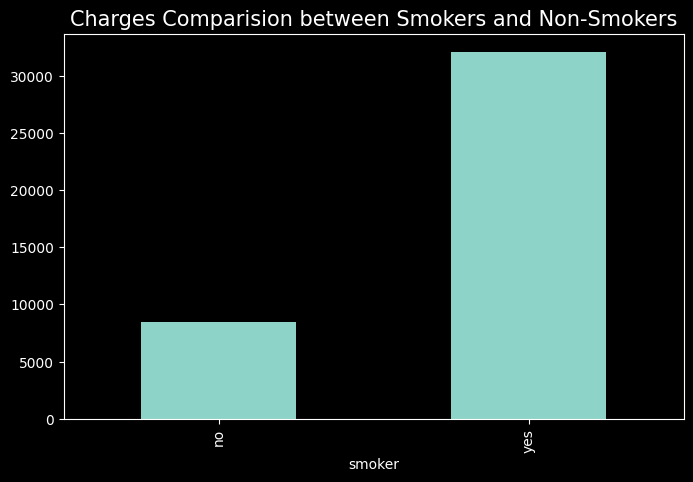

In [38]:
# ================================ Comparison between Smokers and Non-Smokers ===========================


print(data.groupby("smoker")["charges"].mean())

# For better understanding the data (basic visualisation)
plt.figure(figsize = (8,5))

plt.title("Charges Comparison between Smokers and Non-Smokers",fontsize = 15)
data.groupby("smoker")["charges"].mean().plot(kind = "bar",width = 0.5)
plt.show()

# There was high percentage of smoker haiving high charges. So Smoking is a major part for high charges according to Data
# From the Data smokers have to pay double charges as compare to non-smokers


## Analysis between Medical Charges and Children

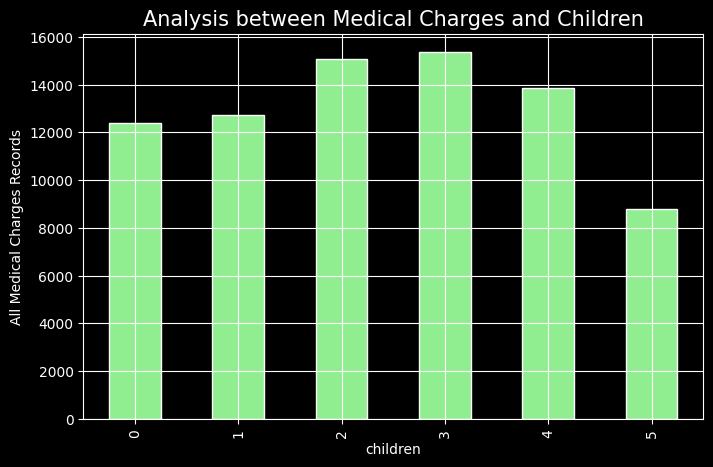


The Correlation between medical charges and Childrens is 'Weak Positive correltion'
       Due to People who having more children they not need to pay high medical charges instead
       People who having less number of children have to pay more medical charges
       (According to Data)


Correlation between Medical Charges and Childrens : 
           children   charges
children  1.000000  0.067389
charges   0.067389  1.000000


In [39]:
# ================================ Analysis between Medical Charges and Children =====================================


plt.figure(figsize = (8,5))

plt.title("Analysis between Medical Charges and Children",fontsize = 15)

plt.xlabel("Number of Children")
plt.ylabel("All Medical Charges Records")

data.groupby("children")["charges"].mean().plot(kind = 'bar',edgecolor = "white",width = 0.5,color = "lightgreen")

plt.grid()
plt.show()

# People who having more children they not need to pay high medical charges instead
# People who having no children they have to pay high medical charges.


print("""\nThe Correlation between medical charges and Children is 'Weak Positive correltion'
       Due to People who having more children they not need to pay high medical charges instead
       People who having less number of children have to pay more medical charges
       (According to Data)\n\n""")

print("Correlation between Medical Charges and Children : \n",data.loc[:,["children","charges"]].corr())



## Analysis between Medical Charges and Region(Area)

In [40]:
# ================================ Analysis between Medical Charges and Region(Area) =============================


print("Analysis between Medical Charges and Region(Area): \n",data.groupby("region")["charges"].agg(["mean","max","min"]))

# In the southeast direction there was high medical insurance charges
# In southwest and east direction there was less medical insurance charges


Analysis between Medical Charges and Region(Area): 
                    mean          max        min
region                                         
northeast  13406.384516  58571.07448  1694.7964
northwest  12450.840844  60021.39897  1621.3402
southeast  14735.411438  63770.42801  1121.8739
southwest  12346.937377  52590.82939  1241.5650


## Data Encoding

In [41]:
# ================================ Conversion of "text" Data into "numeric" Data ==========================


data["smoker"] = data["smoker"].astype("category")
data["sex"] = data["sex"].astype("category")
data["region"] = data["region"].astype("category")

print("\nChecking of Data Type stored in each Features: ")
print(data.dtypes)

data = pd.get_dummies(data,columns = ["sex","smoker","region"],drop_first = True)




Checking of Data Type stored in each Features: 
age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object


## Data Selection

In [42]:
# ============================== Data Selection ==================================

X = data.drop("charges",axis = 1)

y = data["charges"]

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)



## Prediction of Data By Machine Learning


Accuracy of Predicted Data (R square): 
 0.8069287081198011

Mean Absolute Error: 
 4177.045561036319

Root Mean Sqaured error: 
 5956.342894363588

How much each feature affecting the predicted data: 
                    Coefficient
smoker_yes        23077.764593
children            533.009989
bmi                 318.701441
age                 248.210720
sex_male           -101.542054
region_northwest   -391.761455
region_southwest   -659.139752
region_southeast   -838.919616

Intercept of the equation: 
 -11092.65229594595


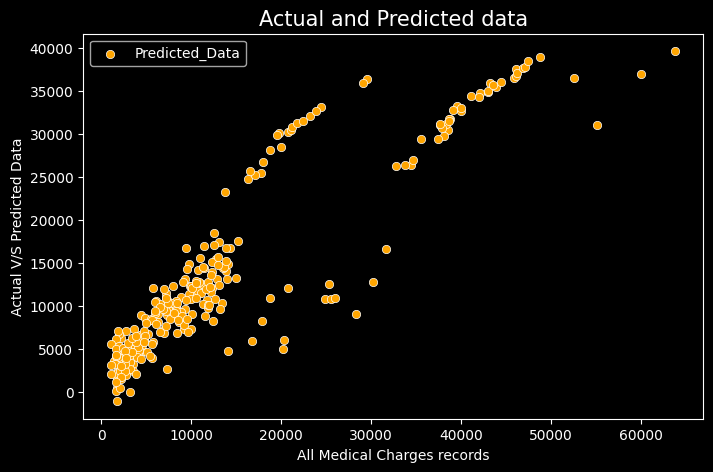

In [43]:
# ================================ Prediction of Data By Machine Learning ==========================


# Many Feature Linear Regression
# We use 'Linear Regression' due to predict the continuous value
# Best for predicting numeric value and the relationship between feature was good to predict data from Linear Regression

model = LinearRegression()

model.fit(x_train,y_train)

pred_data = model.predict(x_test)
# print("Predicted Data of Medical Charges: \n",pred_data)

r2 = r2_score(y_test,pred_data)
print("\nAccuracy of Predicted Data (R square): \n",r2)

# The Prediction of Data by machine was very much good
# If the prediction of Data increases then the machine face difficulties to predict the data with good accuracy

MAE = mean_absolute_error(y_test,pred_data)
RMSE = root_mean_squared_error(y_test,pred_data)

print("\nMean Absolute Error: \n",MAE)
print("\nRoot Mean Sqaured error: \n",RMSE)

coef_df = pd.DataFrame(dict(Coefficient = model.coef_),index = X.columns)

print("\nHow much each feature affecting the predicted data: \n",coef_df.sort_values(by = "Coefficient",ascending = False))

print("\nIntercept of the equation: \n",model.intercept_)

plt.figure(figsize = (8,5))

plt.title("Actual and Predicted data",fontsize = 15)

plt.xlabel("All Medical Charges records")
plt.ylabel("Actual V/S Predicted Data")

plt.scatter(y_test,pred_data,color = "orange",label = "Predicted_Data",marker = "o",edgecolor = "white",linewidth = 0.5)

plt.legend()
plt.show()